# Local Degrees of Freedom

We analyze how many independent motions preserve the Kaleidocycle constraints at a given configuration, using four complementary tools:

- **`rigidity_svd()`** — the constraint Jacobian as a rigidity matrix; returns mechanism and self-stress bases.
- **`calladine_summary()`** — Pellegrino/Calladine rank bookkeeping for mechanisms and self-stresses.
- **`connelly_second_order_test()`** — stress-weighted second variation on infinitesimal mechanisms.
- **`kc.local_dof()` / `kc.finite_motion_dof()`** — infinitesimal and finite-motion DoF using predictor-corrector continuation.

The notebook uses `BACKEND = "jax"` for Jacobian-based computations wherever the current APIs support it. This gives substantially cleaner singular values than finite-difference Jacobians in the rank-deficiency tests.

| Section | Configuration | Expected behaviour |
|---|---|---|
| 1 | Generic feasible (random) | inf_dof = N − 6 (K–G generic) |
| 2 | mean_cos-optimized (Möbius) | inf_dof = N − 5, finite_dof = 1 |
| 3 | Elliptic theta + `find_nearby_stationary` | same as above |

The package API used throughout:

- `rigidity_svd(..., backend=BACKEND)` for the rigidity matrix, mechanisms, and self-stresses.
- `calladine_summary(..., backend=BACKEND)` for Pellegrino/Calladine counting.
- `connelly_second_order_test(..., backend=BACKEND)` for stress-weighted second-order checks.
- `kc.local_dof(config=..., tol=LOCAL_RANK_TOL, backend=BACKEND)` for the K-G linear count.
- `kc.finite_motion_dof(config=..., nullspace_tol=LOCAL_RANK_TOL, backend=BACKEND)` for the nonlinear count.
- `kc.find_nearby_stationary(energy='mean_cos', config=..., backend=BACKEND)` to snap a theta solution onto a stationary point.
- `trace_finite_motion(..., backend=BACKEND)` for predictor–corrector continuation.
- `plot_vertex_trajectories` and `trajectory_dimensionality` for vertex-level visualization and diagnostics.

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

from kaleidocycle import (
    ConstraintConfig,
    Kaleidocycle,
    KaleidocycleAnimation,
    align_first_three,
    binormals_to_curve,
    calladine_summary,
    check_stationarity,
    connelly_second_order_test,
    generate_theta_binormals,
    plot_band,
    plot_vertex_trajectories,
    rigidity_svd,
    trace_finite_motion,
    trajectory_dimensionality,
)
from kaleidocycle.optimality import _newton_correct
from kaleidocycle.theta import solve_closure_conditions

BACKEND = "jax"
LOCAL_RANK_TOL = 1e-6
RIGIDITY_RANK_TOL = 1e-8


def kg_config(kc, fix_torsion_value=True):
    """Build the Kutzbach-Grübler 'physical' ConstraintConfig.

    Uses full 3-D alignment (``full_alignment=True``) so the alignment
    constraint contributes rank 3 to the Jacobian. By default the
    constant-torsion value is also pinned to ``h[0]·h[1]`` at the input
    configuration; set ``fix_torsion_value=False`` (e.g. for
    ``find_nearby_stationary``) to keep only constancy of the torsion.
    """
    cfg = ConstraintConfig(
        oriented=kc.oriented,
        constant_torsion=True,
        alignment=True,
        closure=True,
        full_alignment=True,
    )
    if fix_torsion_value:
        cfg.reference_torsion = float(np.dot(kc.hinges[0], kc.hinges[1]))
    return cfg


def near_zero_count(sv, rel_tol=LOCAL_RANK_TOL):
    """Count near-zero singular values."""
    sv = np.asarray(sv)
    s_max = float(sv.max()) if sv.size else 1.0
    strict = max(sv.shape[0] if sv.ndim else 1, 1) * np.finfo(float).eps * s_max
    return int(np.sum((sv > strict) & (sv <= rel_tol * max(s_max, 1.0))))


def rigidity_report(kc, config, label, *, tol=RIGIDITY_RANK_TOL):
    """Print Calladine/Pellegrino diagnostics using the JAX Jacobian."""
    rig = rigidity_svd(kc.hinges, config, tol=tol, backend=BACKEND)
    summary = calladine_summary(kc.hinges, config, tol=tol, backend=BACKEND)
    print(label)
    print(
        f"  rank={summary.rank}, variables={summary.n_variables}, "
        f"constraints={summary.n_constraints}"
    )
    print(
        f"  mechanisms={summary.mechanisms}, rigid={summary.rigid_mechanisms}, "
        f"internal={summary.internal_mechanisms}, self_stresses={summary.self_stresses}"
    )
    print(
        f"  Calladine index={summary.calladine_index}, "
        f"expected={summary.expected_index}"
    )
    print(f"  smallest singular values: {rig.singular_values[-5:]}")
    return rig, summary


def connelly_report(kc, config, label, *, tol=RIGIDITY_RANK_TOL):
    """Run a Connelly stress test when a self-stress is available."""
    rig = rigidity_svd(kc.hinges, config, tol=tol, backend=BACKEND)
    if rig.self_stress_count == 0:
        print(f"{label}: no self-stress; Connelly test is skipped.")
        return None
    local = kc.local_dof(
        config=config,
        tol=LOCAL_RANK_TOL,
        return_basis=True,
        backend=BACKEND,
    )
    if local["dof"] == 0:
        print(f"{label}: no internal mechanism basis; Connelly test is skipped.")
        return None
    tangent_basis = local["basis"].reshape(kc.hinges.size, local["dof"])
    test = connelly_second_order_test(
        kc.hinges,
        config,
        stress_index=0,
        tangent_basis=tangent_basis,
        tol=tol,
        backend=BACKEND,
    )
    print(f"{label}: Connelly eigenvalues = {test.eigenvalues}")
    return test


## Part 1 — Generic feasible Kaleidocycle

A *generic* feasible configuration is one at a smooth point of the constraint variety. We construct one by starting from random unit hinges and Newton-projecting onto the manifold — no specific energy is optimized. The result should have full row rank (no near-zero singular values) and `inf_dof = N − 6` (the Kutzbach–Grübler generic count).

In [3]:
N = 10
kc_gen = Kaleidocycle(N, oriented=False, solver_options={"mode": "random_feasible"})
cfg_gen = kg_config(kc_gen)  # pin torsion at the current value

inf = kc_gen.local_dof(config=cfg_gen, tol=LOCAL_RANK_TOL, backend=BACKEND)
near0 = near_zero_count(inf["singular_values"])
print(f"Generic feasible kaleidocycle, N={N}:")
print(f"  inf_dof = {inf['dof']:>3d}  (K-G predicts N - 6 = {N - 6})")
print(f"  near0    = {near0}")
print(f"  mean_cos = {kc_gen.mean_cosine:.4f}")

Generic feasible kaleidocycle, N=10:
  inf_dof =   4  (K-G predicts N - 6 = 4)
  near0    = 0
  mean_cos = 0.2107


### Rigidity matrix and Calladine/Pellegrino count

The same JAX-computed constraint Jacobian can be read as a rigidity matrix. Its right nullspace gives infinitesimal mechanisms; its left nullspace gives self-stresses. The Calladine/Pellegrino identity is a useful consistency check before doing nonlinear continuation.


In [4]:
rig_gen, call_gen = rigidity_report(kc_gen, cfg_gen, "Generic feasible")
_ = connelly_report(kc_gen, cfg_gen, "Generic feasible")


Generic feasible
  rank=26, variables=33, constraints=26
  mechanisms=7, rigid=3, internal=4, self_stresses=0
  Calladine index=4, expected=4
  smallest singular values: [0.94607405 0.88444612 0.86321973 0.53528948 0.37488193]
Generic feasible: no self-stress; Connelly test is skipped.


In [5]:
fin = kc_gen.finite_motion_dof(
    config=cfg_gen, nullspace_tol=LOCAL_RANK_TOL,
    seed=0, step_size=2e-5, n_steps=12, n_samples=max(2 * inf['dof'], 8),
    backend=BACKEND,
)
print(f"finite_dof = {fin['finite_dof']}, n_successful = {fin['n_successful']}")
print(f"top displacement singular values: {fin['displacement_singular_values'][:5]}")


finite_dof = 4, n_successful = 8
top displacement singular values: [1.84484924e+00 1.39750591e+00 1.23674215e+00 1.05545125e+00
 1.09634724e-04]


### Random sampling test of the variety dimension

A direct way to see whether the local motion is genuinely 1-D or higher: take many random perturbations, Newton-project onto the manifold, and look at the spread of vertex positions. For a generic feasible point with `inf_dof = N − 6` motions, the samples will fill a higher-dimensional patch (per-vertex `σ₂/σ₁` is sizeable). Compare this with the Möbius random-sampling experiment in Part 4 where samples accumulate on a 1-D curve.

accepted samples: 201 / 201
sample σ₂/σ₁ per vertex: mean=0.4097, max=0.6936  →  broad spread indicates higher-dimensional sampling


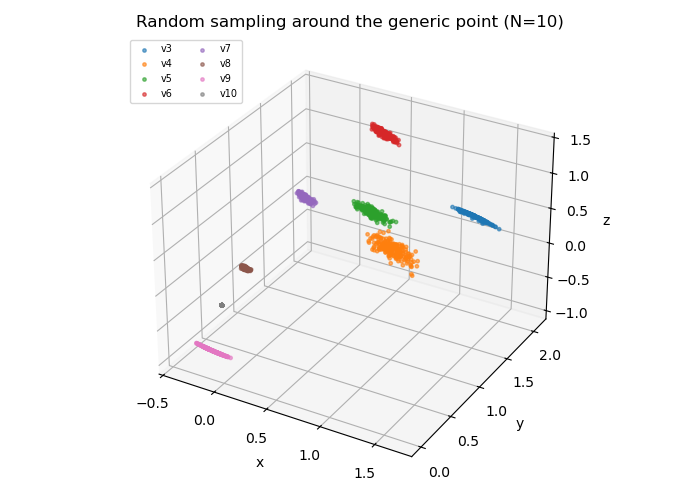

In [6]:
from kaleidocycle.optimality import _newton_correct as _nc

def _random_sample(kc, config, *, n_samples=200, perturbation_scale=0.08, seed=0):
    rng = np.random.default_rng(seed)
    h0 = kc.hinges.copy()
    accepted = [h0.copy()]
    for _ in range(n_samples):
        h_pert = h0 + perturbation_scale * rng.standard_normal(h0.shape)
        h_pert = h_pert / np.linalg.norm(h_pert, axis=1, keepdims=True)
        h_proj = _nc(h_pert, config, tol=1e-9, max_iter=200,
                     finite_diff_step=1e-8, backend=BACKEND)
        if h_proj is not None:
            accepted.append(h_proj)
    return np.array(accepted)


samples_gen = _random_sample(kc_gen, cfg_gen, n_samples=200, seed=1)
curves_samples_gen = np.array([
    align_first_three(binormals_to_curve(h, center=False)) for h in samples_gen
])
print(f"accepted samples: {samples_gen.shape[0]} / 201")

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
cmap = plt.get_cmap("tab10")
for k, v in enumerate(range(3, curves_samples_gen.shape[1])):
    pts = curves_samples_gen[:, v, :]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6,
               color=cmap(k % 10), alpha=0.6, label=f"v{v}")
ax.set_title(f"Random sampling around the generic point (N={N})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

diag = trajectory_dimensionality(curves_samples_gen)
print(f"sample σ₂/σ₁ per vertex: mean={diag['mean']:.4f}, "
      f"max={diag['max']:.4f}  →  broad spread indicates higher-dimensional sampling")

## Part 2 — mean_cos-optimized (Möbius) Kaleidocycle

`Kaleidocycle(n=N, oriented=...)` constructs a configuration that optimizes `mean_cos` — the Möbius kaleidocycle, characterized by the rank-deficiency signature `near0 = 1` (one extra near-zero singular value in J) and `inf_dof = N − 5` (one more than the K-G generic count). The 1-DoF conjecture says that, despite the inflated linear count, only a **single** direction integrates to a finite motion — visible as vertex trajectories that lie on 1-D curves.

In [7]:
N = 9
kc_mob = Kaleidocycle(n=N, oriented=True, seed=0)
cfg_mob = kg_config(kc_mob)

inf = kc_mob.local_dof(config=cfg_mob, tol=LOCAL_RANK_TOL, backend=BACKEND)
near0 = near_zero_count(inf["singular_values"])
print(f"Möbius kaleidocycle, N={N}, mean_cos = {kc_mob.mean_cosine:.4f}:")
print(f"  inf_dof = {inf['dof']:>3d}  (N - 5 = {N - 5})")
print(f"  near0    = {near0}   (Möbius signature)")

rig_mob, call_mob = rigidity_report(kc_mob, cfg_mob, "Möbius rigidity")
_ = connelly_report(kc_mob, cfg_mob, "Möbius rigidity")

fin = kc_mob.finite_motion_dof(
    config=cfg_mob, nullspace_tol=LOCAL_RANK_TOL,
    seed=0, step_size=1e-4, n_steps=10, n_samples=12,
    backend=BACKEND,
)
sigma = fin["displacement_singular_values"]
print(f"  finite_dof = {fin['finite_dof']}, σ₂/σ₁ = {sigma[1] / sigma[0]:.4f}")

Möbius kaleidocycle, N=9, mean_cos = -0.5852:
  inf_dof =   4  (N - 5 = 4)
  near0    = 1   (Möbius signature)
Möbius rigidity
  rank=24, variables=30, constraints=24
  mechanisms=6, rigid=3, internal=3, self_stresses=0
  Calladine index=3, expected=3
  smallest singular values: [8.12272881e-01 7.67285913e-01 6.33826872e-01 5.73528566e-01
 5.02651466e-08]
Möbius rigidity: no self-stress; Connelly test is skipped.
  finite_dof = 4, σ₂/σ₁ = 0.5119


frames: (241, 10, 3)
mean σ₂/σ₁ across free vertices: 0.0091  (close to 0 → essentially 1-D motion)


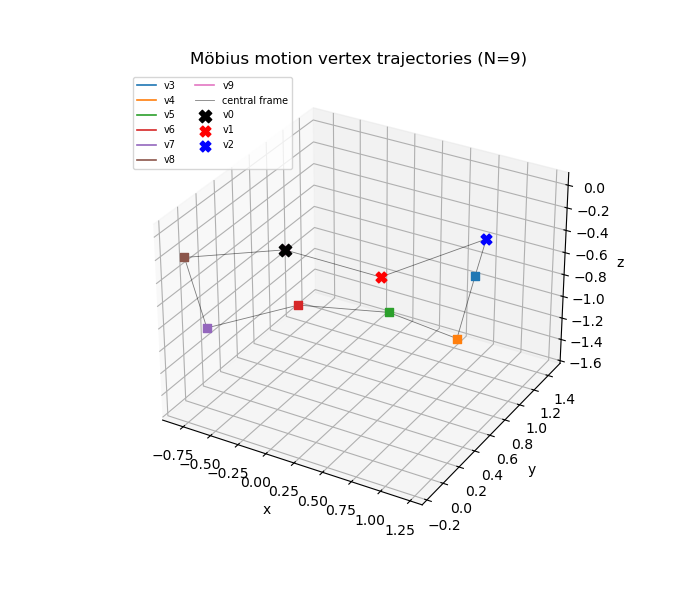

In [8]:
frames_mob = trace_finite_motion(
    kc_mob.hinges, cfg_mob, direction_index=0,
    step_size=5e-4, n_steps=120, nullspace_tol=LOCAL_RANK_TOL,
    backend=BACKEND,
)
print(f"frames: {frames_mob.shape}")

_, curves_mob = plot_vertex_trajectories(
    frames_mob,
    title=f"Möbius motion vertex trajectories (N={N})",
)
diag = trajectory_dimensionality(curves_mob)
print(f"mean σ₂/σ₁ across free vertices: {diag['mean']:.4f}  "
      f"(close to 0 → essentially 1-D motion)")

accepted samples: 201 / 201
sample σ₂/σ₁ per vertex: mean=0.0626, max=0.3037  →  smaller values support 1-D sampling


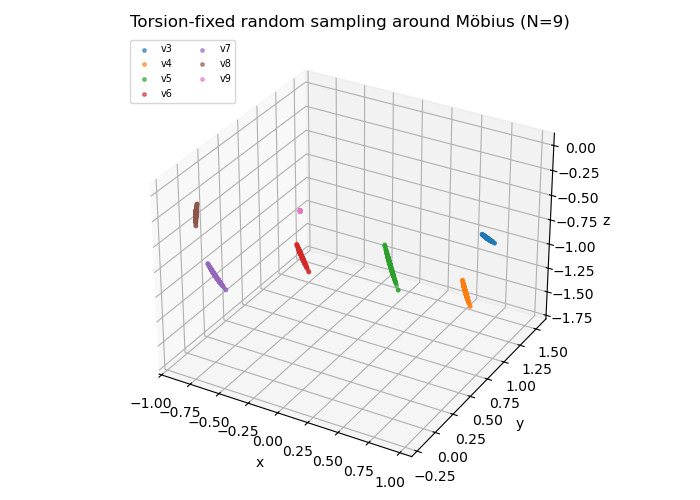

In [ ]:
### Random sampling test of the variety dimension
samples_mob = _random_sample(kc_mob, cfg_mob, n_samples=200, seed=1)
curves_samples_mob = np.array([
    align_first_three(binormals_to_curve(h, center=False)) for h in samples_mob
])
print(f"accepted samples: {samples_mob.shape[0]} / 201")

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
cmap = plt.get_cmap("tab10")
for k, v in enumerate(range(3, curves_samples_mob.shape[1])):
    pts = curves_samples_mob[:, v, :]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6,
               color=cmap(k % 10), alpha=0.6, label=f"v{v}")
ax.set_title(f"Torsion-fixed random sampling around Möbius (N={N})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

diag = trajectory_dimensionality(curves_samples_mob)
print(f"sample σ₂/σ₁ per vertex: mean={diag['mean']:.4f}, "
      f"max={diag['max']:.4f}  →  smaller values support 1-D sampling")

## Part 3 — Elliptic theta + `find_nearby_stationary`

The theta-function construction yields a kaleidocycle that is (close to) a stationary point of `mean_cos`. These are saddle points — gradient descent diverges from them — so we use `find_nearby_stationary`, which solves $\Pi_{\ker J}\nabla E = 0$ directly with Powell's hybrid method.

For small `(N, m)` cases such as `(7, 3)` and `(8, 3)` the theta solution is **already** stationary to machine precision. For `(9, 3)` and `(15, 5)` the solver moves a bit before converging onto the nearby stationary.

In [11]:
theta_cases = [
    (7,  3, (0.48, 0.27)),
    (8,  3, (0.40, 0.72)),
    (9,  3, (0.34, 0.29)),
    (15, 5, (0.40, 0.69)),
]

print(f"{'N':>3} {'m':>2} {'||pg||':>10} {'dist':>7} "
      f"{'inf_dof':>8} {'K-G':>4} {'near0':>6} {'mean_cos':>10}")
print("-" * 72)

theta_stationaries = {}
for N, m, ig in theta_cases:
    v, r, y = solve_closure_conditions(N, m=m, initial_guess=ig)
    #print(f"theta solution for N={N}, m={m}: v={v:.4f}, r={r:.4f}, y={y:.4f}")
    binormals = generate_theta_binormals(v, 0.0, r, y, N=N, t=0.1)
    kc_theta = Kaleidocycle(hinges=binormals)

    kc_stat = kc_theta.find_nearby_stationary(
        energy="mean_cos",
        config=kg_config(kc_theta, fix_torsion_value=False),
        backend=BACKEND,
    )
    info_stat = kc_stat.metadata["stationary_info"]
    cfg = kg_config(kc_stat)
    inf = kc_stat.local_dof(config=cfg, tol=LOCAL_RANK_TOL, backend=BACKEND)
    near0 = near_zero_count(inf["singular_values"])
    theta_stationaries[(N, m)] = kc_stat
    print(
        f"{N:>3} {m:>2} {info_stat['projected_gradient_norm']:>10.2e} "
        f"{info_stat['distance']:>7.3f} {inf['dof']:>8} {N - 6:>4} {near0:>6} "
        f"{kc_stat.mean_cosine:>10.4f}"
    )

  N  m     ||pg||    dist  inf_dof  K-G  near0   mean_cos
------------------------------------------------------------------------


  7  3   1.81e-12   0.000        2    1      1     0.2954
  8  3   1.71e-13   0.000        3    2      0     0.4700
  9  3   1.74e-11   0.000        4    3      1     0.5852
 15  5   2.97e-12   0.000       10    9      1     0.6497


theta(N=15, m=5) rigidity
  rank=35, variables=48, constraints=36
  mechanisms=13, rigid=3, internal=10, self_stresses=1
  Calladine index=9, expected=9
  smallest singular values: [6.56568702e-01 6.53356308e-01 6.33194806e-01 5.08327241e-01
 8.67821360e-12]
theta rigidity: Connelly eigenvalues = [-7.15851604e-02 -6.79040808e-02  1.34954840e-09  4.67115975e-02
  5.24698438e-02  3.21468713e-01  3.39569851e-01  5.56064565e-01
  6.03076362e-01  6.56480129e-01]
frames: (201, 16, 3)
mean σ₂/σ₁: 0.0101  (≈ 0 → 1-D motion confirmed)


{'is_stationary': True,
 'projected_gradient_norm': 2.457901785162129e-12,
 'gradient_norm': 0.21909742589152179,
 'constraint_penalty': 9.715935103224504e-18,
 'details': {'energy': 'mean_cos',
  'tolerance': 1e-06,
  'finite_diff_step': 1e-08,
  'n_constraints': 36,
  'n_variables': 48,
  'constraint_rank': 36,
  'backend': 'jax'}}

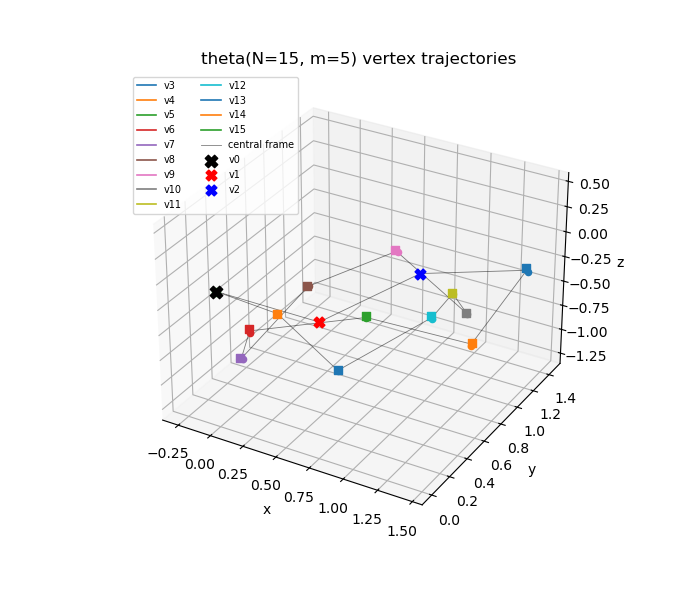

In [ ]:
# Vertex-trajectory plot
theta_key = (15, 5)
kc_theta = theta_stationaries[theta_key]
cfg = kg_config(kc_theta)
rig_theta, call_theta = rigidity_report(
    kc_theta, cfg, f"theta(N={theta_key[0]}, m={theta_key[1]}) rigidity"
)
_ = connelly_report(kc_theta, cfg, "theta rigidity")

frames_theta = trace_finite_motion(
    kc_theta.hinges, cfg, direction_index=0,
    step_size=3e-4, n_steps=100, nullspace_tol=LOCAL_RANK_TOL,
    backend=BACKEND,
)
print(f"frames: {frames_theta.shape}")

_, curves_theta = plot_vertex_trajectories(
    frames_theta,
    title=f"theta(N={theta_key[0]}, m={theta_key[1]}) vertex trajectories",
)
diag = trajectory_dimensionality(curves_theta)
print(f"mean σ₂/σ₁: {diag['mean']:.4f}  (≈ 0 → 1-D motion confirmed)")
check_stationarity(kc_theta.hinges, "mean_cos", cfg, backend=BACKEND)

accepted samples: 201 / 201
sample σ₂/σ₁ per vertex: mean=0.5278, max=0.8207  →  smaller values support 1-D sampling


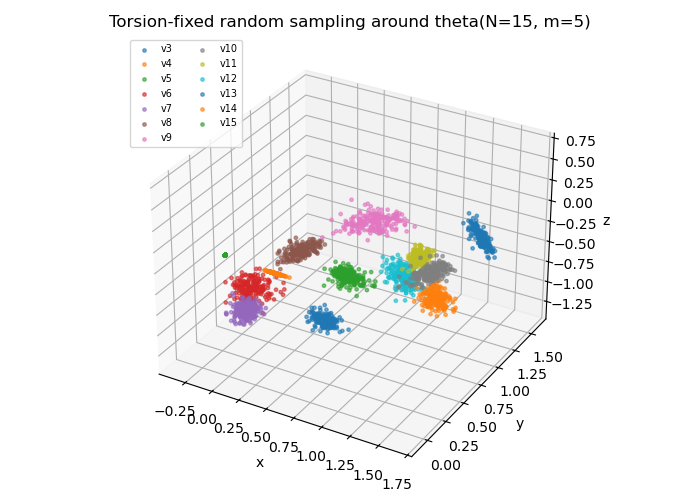

In [13]:
### Random sampling test of the variety dimension
samples_theta = _random_sample(kc_theta, cfg, n_samples=200, seed=1)
curves_samples_theta = np.array([
    align_first_three(binormals_to_curve(h, center=False)) for h in samples_theta
])
print(f"accepted samples: {samples_theta.shape[0]} / 201")

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
cmap = plt.get_cmap("tab10")
for k, v in enumerate(range(3, curves_samples_theta.shape[1])):
    pts = curves_samples_theta[:, v, :]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6,
               color=cmap(k % 10), alpha=0.6, label=f"v{v}")
ax.set_title(f"Torsion-fixed random sampling around theta(N={theta_key[0]}, m={theta_key[1]})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

diag = trajectory_dimensionality(curves_samples_theta)
print(f"sample σ₂/σ₁ per vertex: mean={diag['mean']:.4f}, "
      f"max={diag['max']:.4f}  →  smaller values support 1-D sampling")